In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df =pd.read_csv("healthexp-69bf41e3d6857010224647.csv")
df

,Unnamed: 0,Year,Country,Spending_USD,Life_Expectancy
0,0,1970,Germany,252.311,70.6
1,1,1970,France,192.143,72.2
2,2,1970,Great Britain,123.993,71.9
3,3,1970,Japan,150.437,72.0
4,4,1970,USA,326.961,70.9
...,...,...,...,...,...
269,269,2020,Germany,6938.983,81.1
270,270,2020,France,5468.418,82.3
271,271,2020,Great Britain,5018.700,80.4
272,272,2020,Japan,4665.641,84.7


In [2]:
#Déterminez quelles sont les variables Discrètes et Continues du dataset
df.dtypes

Unnamed: 0           int64
Year                 int64
Country                str
Spending_USD       float64
Life_Expectancy    float64
dtype: object

In [3]:
# 4. Nettoyage
# ==============================
df['Country'] = df['Country'].astype(str)
df['Country'] = df['Country'].str.strip()
df['Country'] = df['Country'].str.title()


In [4]:
# 5. Valeurs manquantes
# ==============================
missing = df['Country'].isnull().sum()
print("\nValeurs manquantes :", missing)



Valeurs manquantes : 0


In [5]:
# 6. Nombre de pays uniques
# ==============================
unique_countries = df['Country'].nunique()
print("Nombre de pays uniques :", unique_countries)

Nombre de pays uniques : 6


In [6]:
# 7. Fréquences
# ==============================
freq = df['Country'].value_counts()
print("\nFréquences :")
print(freq)



Fréquences :
Country
Japan            51
Usa              51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64


In [ ]:
# 8. Pourcentages
# ==============================
percent = df['Country'].value_counts(normalize=True) * 100
print("\nPourcentages (%) :")
print(percent.round(2))

SyntaxError: invalid decimal literal (895435220.py, line 3)

In [8]:
# 10. Pays dominant
# ==============================
total = len(df)
top_country = freq.index[0]
top_count = freq.iloc[0]
dominance = (top_count / total) * 100

print(f"\nPays dominant : {top_country} ({round(dominance,2)}%)")



Pays dominant : Japan (18.61%)


In [9]:
# 11. Interprétation
# ==============================
print("\n--- Interprétation ---")

print("Diversité :", 
      "faible" if unique_countries < 5 
      else "moyenne" if unique_countries < 20 
      else "élevée")

print("Distribution :", 
      "très déséquilibrée" if dominance > 50 
      else "déséquilibrée" if dominance > 30 
      else "équilibrée")



--- Interprétation ---
Diversité : moyenne
Distribution : équilibrée


In [10]:
print("=== ANALYSE DE LA VARIABLE 'Spending_USD' ===\n")

# ==============================
# 3. Type de la variable
# ==============================
print("Type :", df['Spending_USD'].dtype)

# ==============================
# 4. Valeurs manquantes
# ==============================
missing = df['Spending_USD'].isnull().sum()
print("\nValeurs manquantes :", missing)

# ==============================
# 5. Statistiques descriptives
# ==============================
print("\nStatistiques :")
print(df['Spending_USD'].describe())

# ==============================
# 6. Mesures importantes
# ==============================
mean = df['Spending_USD'].mean()
median = df['Spending_USD'].median()
std = df['Spending_USD'].std()
min_val = df['Spending_USD'].min()
max_val = df['Spending_USD'].max()

print(f"\nMoyenne : {round(mean,2)}")
print(f"Médiane : {round(median,2)}")
print(f"Écart-type : {round(std,2)}")
print(f"Min : {min_val}")
print(f"Max : {max_val}")


# 7. Détection des valeurs extrêmes (outliers)

Q1 = df['Spending_USD'].quantile(0.25)
Q3 = df['Spending_USD'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Spending_USD'] < lower_bound) | (df['Spending_USD'] > upper_bound)]

print("\nNombre de valeurs aberrantes :", len(outliers))



=== ANALYSE DE LA VARIABLE 'Spending_USD' ===

Type : float64

Valeurs manquantes : 0

Statistiques :
count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64

Moyenne : 2789.34
Médiane : 2295.58
Écart-type : 2194.94
Min : 123.993
Max : 11859.179

Nombre de valeurs aberrantes : 7


In [11]:

# 8. Analyse de la distribution

print("\n--- Interprétation ---")

if mean > median:
    print("Distribution asymétrique à droite (présence de grosses dépenses)")
elif mean < median:
    print("Distribution asymétrique à gauche")
else:
    print("Distribution symétrique")

print("Dispersion :", 
      "faible" if std < 10 
      else "moyenne" if std < 50 
      else "élevée")


# 9. Catégorisation 

df['Spending_Category'] = pd.cut(
    df['Spending_USD'],
    bins=[0, 50, 200, 500, float('inf')],
    labels=['Faible', 'Moyen', 'Élevé', 'Très élevé']
)

print("\nRépartition par catégorie :")
print(df['Spending_Category'].value_counts())



--- Interprétation ---
Distribution asymétrique à droite (présence de grosses dépenses)
Dispersion : élevée

Répartition par catégorie :
Spending_Category
Très élevé    246
Élevé          22
Moyen           6
Faible          0
Name: count, dtype: int64


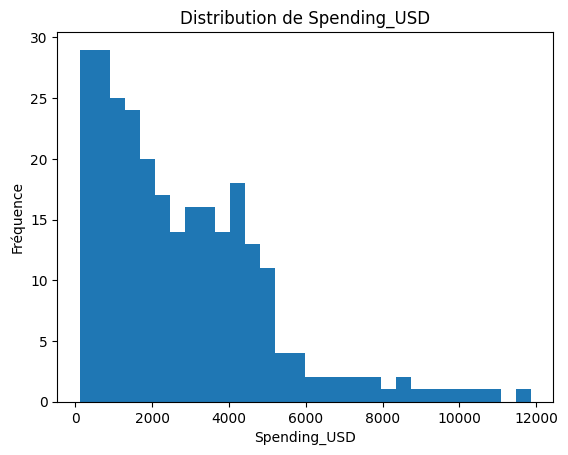

In [12]:
# 1. Histogramme
# ==============================
plt.figure()
plt.hist(df['Spending_USD'], bins=30)

plt.title("Distribution de Spending_USD")
plt.xlabel("Spending_USD")
plt.ylabel("Fréquence")

plt.show()



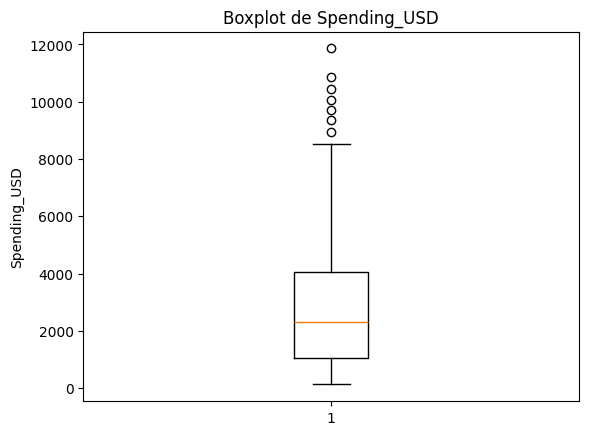

In [13]:
# ==============================
# 2. Boxplot
# ==============================
plt.figure()
plt.boxplot(df['Spending_USD'])

plt.title("Boxplot de Spending_USD")
plt.ylabel("Spending_USD")

plt.show()